# Libraries Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset Load

In [2]:
df = pd.read_csv("Stockprices.csv")
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [3]:
df['symbol'].unique()

array(['AAL', 'AAPL', 'AAP', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI',
       'ADM', 'ADP', 'ADSK', 'ADS', 'AEE', 'AEP', 'AES', 'AET', 'AFL',
       'AGN', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK',
       'ALLE', 'ALL', 'ALXN', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMG', 'AMP',
       'AMT', 'AMZN', 'ANDV', 'ANSS', 'ANTM', 'AON', 'AOS', 'APA', 'APC',
       'APD', 'APH', 'ARE', 'ARNC', 'ATVI', 'AVB', 'AVGO', 'AVY', 'AWK',
       'AXP', 'AYI', 'AZO', 'A', 'BAC', 'BAX', 'BA', 'BBT', 'BBY', 'BDX',
       'BEN', 'BF.B', 'BIIB', 'BK', 'BLK', 'BLL', 'BMY', 'BRK.B', 'BSX',
       'BWA', 'BXP', 'CAG', 'CAH', 'CAT', 'CA', 'CBG', 'CBOE', 'CBS',
       'CB', 'CCI', 'CCL', 'CDNS', 'CELG', 'CERN', 'CF', 'CHD', 'CHK',
       'CHRW', 'CHTR', 'CINF', 'CI', 'CLX', 'CL', 'CMA', 'CMCSA', 'CME',
       'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COG', 'COL', 'COO',
       'COP', 'COST', 'COTY', 'CPB', 'CRM', 'CSCO', 'CSX', 'CTAS', 'CTL',
       'CTSH', 'CTXS', 'CVS', 'CVX', 'CXO', 'C', 'DAL', 'D

In [4]:
df['symbol'].nunique()

505

In [6]:
aapl = df[df['symbol'] == 'AAPL']
aapl.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


In [7]:
aapl['date'] = pd.to_datetime(aapl['date'])
aapl.dtypes

C:\Users\USER\AppData\Local\Temp\ipykernel_15800\2040929973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aapl['date'] = pd.to_datetime(aapl['date'])


symbol            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

In [8]:
aapl = aapl.sort_values('date')
aapl = aapl.set_index('date')
aapl.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


# Time Series Plot

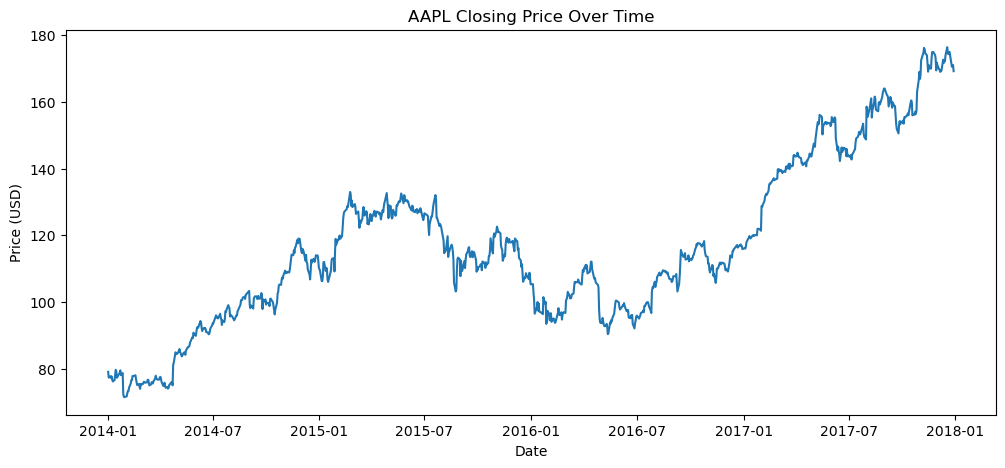

In [9]:
plt.figure(figsize=(12,5))
plt.plot(aapl.index, aapl['close'])
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

In [10]:
aapl['MA20'] = aapl['close'].rolling(window=20).mean()
aapl[['close', 'MA20']].head(25)

,close,MA20
date,,
2014-01-02,79.0185,NaN
2014-01-03,77.2828,NaN
2014-01-06,77.7042,NaN
2014-01-07,77.1481,NaN
2014-01-08,77.6371,NaN
2014-01-09,76.6455,NaN
2014-01-10,76.1342,NaN
2014-01-13,76.5328,NaN
2014-01-14,78.0556,NaN


In [11]:
aapl['MA50'] = aapl['close'].rolling(window=50).mean()

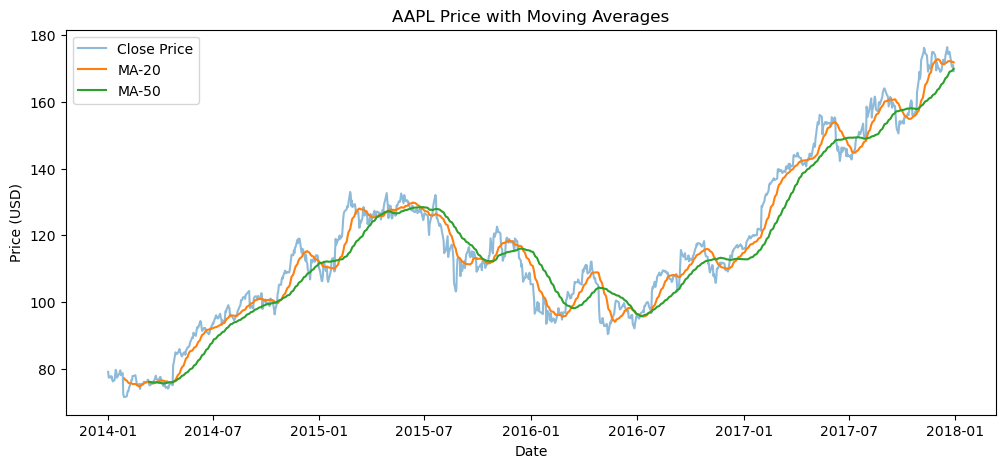

In [12]:
plt.figure(figsize=(12,5))
plt.plot(aapl.index, aapl['close'], label='Close Price', alpha=0.5)
plt.plot(aapl.index, aapl['MA20'], label='MA-20')
plt.plot(aapl.index, aapl['MA50'], label='MA-50')
plt.title("AAPL Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# Statsmodels Import

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Monthly Data

In [14]:
monthly = aapl['close'].resample('ME').mean()
monthly.head()

date
2014-01-31    76.777876
2014-02-28    75.225637
2014-03-31    76.173400
2014-04-30    77.296243
2014-05-31    86.170752
Freq: ME, Name: close, dtype: float64

In [15]:
result = seasonal_decompose(monthly, model='multiplicative', period=12)

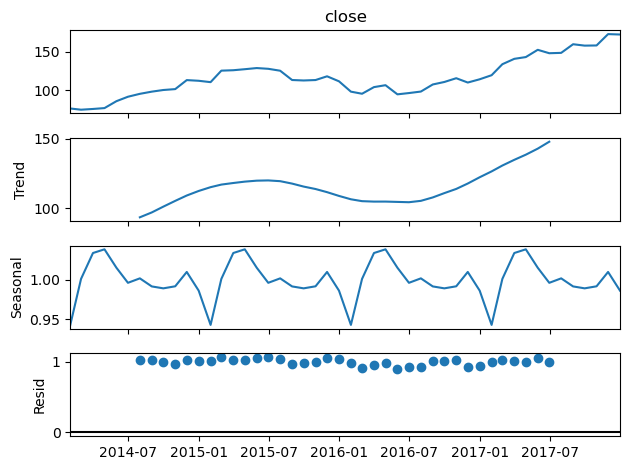

In [16]:
result.plot()
plt.show()